##### ARTI 560 - Computer Vision  
## Image Classification using Convolutional Neural Networks (CNNs) - Exercise 

### Objective

In this exercise, you will:

1. **Load the Fashion MNIST dataset** from the [Keras dataset](https://keras.io/api/datasets/) website.
2. **Preprocess the data** for training.
3. **Build your own CNN architecture** and evaluate the model.

In [ ]:
# Import libraries
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.datasets import fashion_mnist
import matplotlib.pyplot as plt
import numpy as np
# Load Fashion MNIST data
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# Number of unique classes
num_classes = len(set(y_train))
print("num of unique classes :", num_classes)

num of unique classes : 10


In [7]:
# Define class names
class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]


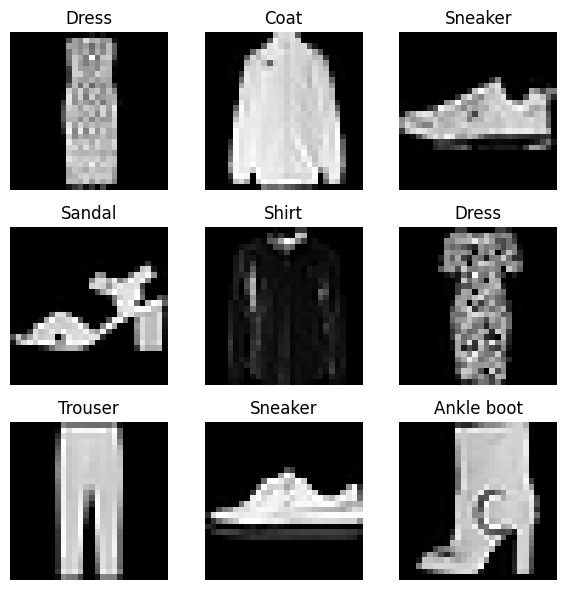

In [8]:
# Plot a 3x3 grid of random images from the dataset with their labels
plt.figure(figsize=(6,6))

for i in range(9):
    index = np.random.randint(0, x_train.shape[0])
    plt.subplot(3, 3, i + 1)
    plt.imshow(x_train[index].reshape(28, 28), cmap="gray")
    plt.title(class_names[y_train[index]])
    plt.axis("off")

plt.tight_layout()
plt.show()

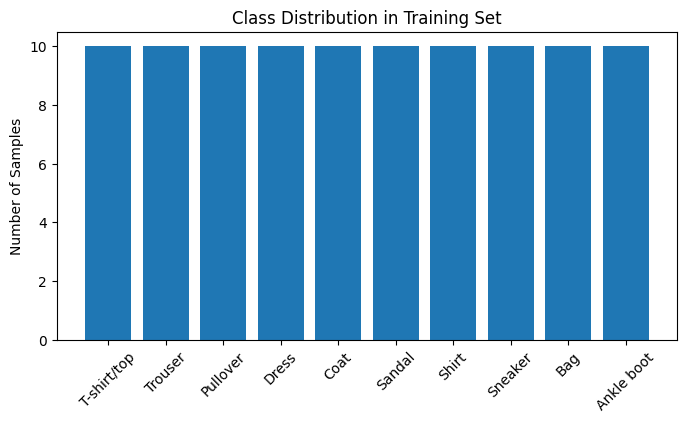

In [9]:
# Count occurrences of each class in the training set

# Plot the class distribution

import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.bar(class_names, num_classes)
plt.xticks(rotation=45)
plt.title("Class Distribution in Training Set")
plt.ylabel("Number of Samples")
plt.show()


In [16]:
print("x_train shape:", x_train.shape)
print("x_train dtype:", x_train.dtype)
print("min/max:", x_train.min(), x_train.max())
print("mean:", x_train.mean())


x_train shape: (60000, 28, 28, 1)
x_train dtype: float32
min/max: 0.0 2.3650445e-10
mean: 6.764987e-11


### Build your Image Classification Model
Note: Don't use one hot encoding and use sparse_categorical_crossentropy for loss

In [26]:
# Import libraries
import tensorflow as tf
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.datasets import fashion_mnist

# Load dataset
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# Normalize pixel values (ONCE)
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

# Reshape for CNN
x_train = x_train.reshape(-1, 28, 28, 1)
x_test  = x_test.reshape(-1, 28, 28, 1)

# Labels remain integers (NO one-hot encoding)

# Build a CNN model
model = Sequential([
    Conv2D(32, (3,3), activation="relu", input_shape=(28,28,1)),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation="relu"),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(128, activation="relu"),
    Dense(10, activation="softmax")
])

# Compile the model (SPARSE loss)
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Train the model
model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

# Evaluate the model
loss, accuracy = model.evaluate(x_test, y_test, verbose=0)
print("Test accuracy:", accuracy)


Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.8178 - loss: 0.5045 - val_accuracy: 0.8635 - val_loss: 0.3778
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.8806 - loss: 0.3291 - val_accuracy: 0.8847 - val_loss: 0.3154
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.8962 - loss: 0.2843 - val_accuracy: 0.8907 - val_loss: 0.2971
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9069 - loss: 0.2523 - val_accuracy: 0.9022 - val_loss: 0.2702
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9169 - loss: 0.2264 - val_accuracy: 0.9042 - val_loss: 0.2694
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.9238 - loss: 0.2054 - val_accuracy: 0.9047 - val_loss: 0.2613
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.9302 - loss: 0.1882 - val_accuracy: 0.9135 - val_loss: 0.2410
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - accuracy: 0.9380 - loss: 0.1678 - val_accurac